Défi quotidien : Analyse des accidents d'avion et des décès

Fichiers dans le ZIP : ['Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv']

Aperçu des données :


,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...



Taille : 4998 lignes x 17 colonnes

Colonnes : ['Date', 'Time', 'Location', 'Operator', 'Flight #', 'Route', 'AC Type', 'Registration', 'cn/ln', 'Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Summary']

Valeurs manquantes :
Date                        0
Time                     1512
Location                    4
Operator                   10
Flight #                 3669
Route                     777
AC Type                    15
Registration              274
cn/ln                     668
Aboard                     18
Aboard Passangers         229
Aboard Crew               226
Fatalities                  8
Fatalities Passangers     242
Fatalities Crew           241
Ground                     42
Summary                    64
dtype: int64

Données après nettoyage :


,Date,Year,Fatalities,Aboard,Survivors,SurvivalRate
0,1908-09-17,1908,1.0,2.0,1.0,50.0
1,1909-09-07,1909,1.0,1.0,0.0,0.0
2,1912-07-12,1912,5.0,5.0,0.0,0.0
3,1913-08-06,1913,1.0,1.0,0.0,0.0
4,1913-09-09,1913,14.0,20.0,6.0,30.0



Statistiques générales :
Nombre total d'accidents : 4998
Total des décès : 111732
Taux de survie moyen : 18.23%
Accident le plus meurtrier : 583 morts

Accidents par décennie :
Decade
1900      2
1910     31
1920    182
1930    357
1940    578
1950    649
1960    636
1970    612
1980    552
1990    631
2000    506
2010    235
2020     27
dtype: int64

Statistiques sur les décès :
Moyenne  : 22.36
Médiane  : 11.00
Ecart-type : 35.04
Min : 0
Max : 583

Test T - Décès avant vs après 1980 :
Statistique T : -6.3373
Valeur P : 0.0000
La différence est significative : la sécurité a évolué après 1980


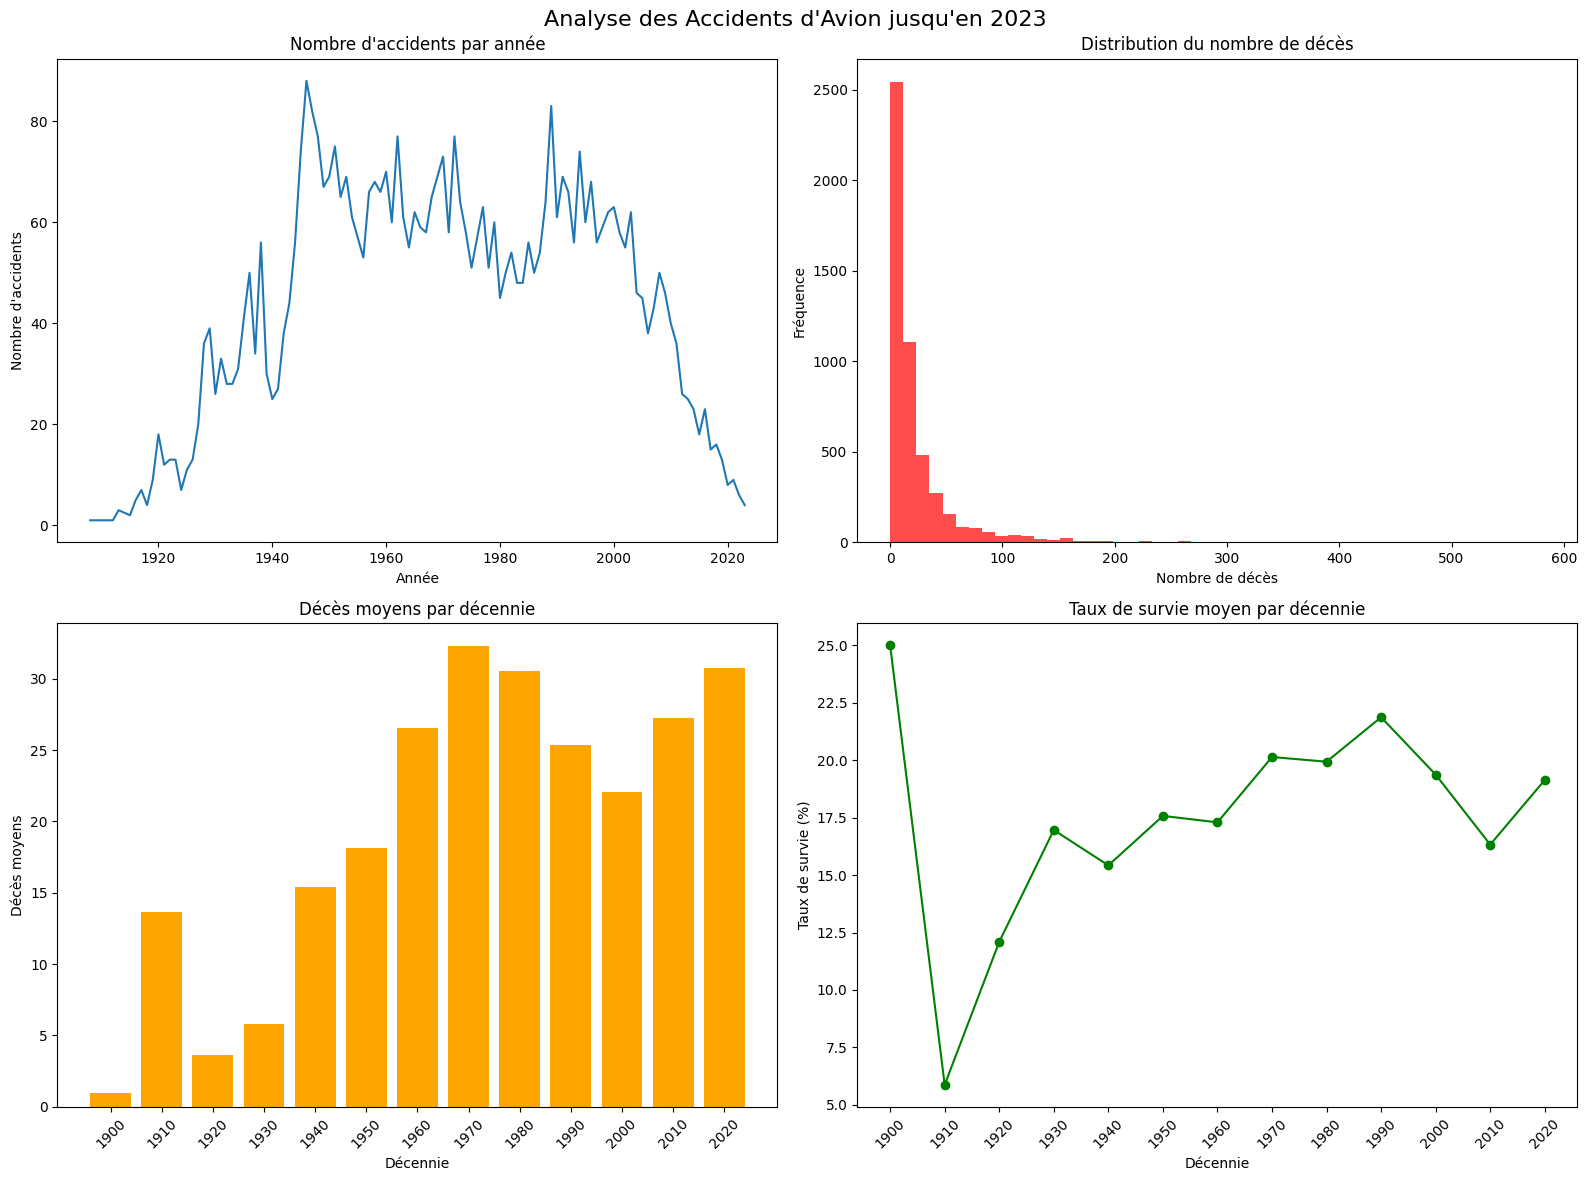


RAPPORT - CONCLUSIONS

1. DONNÉES
   - 4998 accidents analysés au total
   - Période couverte : 1908 à 2023
   - 111732 décès enregistrés au total

2. TENDANCES
   - Le pic d'accidents se situe autour des années 1946
   - Taux de survie moyen : 18.2%
   - Décès médians par accident : 11

3. TEST STATISTIQUE
   - Comparaison avant/après 1980
   - Valeur P : 0.0000
   - La sécurité aérienne s'est significativement améliorée

4. OBSERVATION
   - Les accidents les plus meurtriers ont eu lieu avant 1980
   - Le taux de survie a tendance à augmenter avec les années
   - La fréquence des accidents a diminué depuis les années 1990



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io
from scipy import stats


# IMPORTATION ET NETTOYAGE DES DONNÉES

# chargement du dataset depuis le ZIP
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/W4%20Gen%20AI/W4D3/Airplane%20Crashes%20and%20Fatalities%20upto%202023.zip"

response = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(response.content))
print("Fichiers dans le ZIP :", z.namelist())
df = pd.read_csv(z.open(z.namelist()[0]), encoding='latin-1')

# aperçu général des données
print("\nAperçu des données :")
display(df.head())
print(f"\nTaille : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print("\nColonnes :", df.columns.tolist())
print("\nValeurs manquantes :")
print(df.isnull().sum())

# conversion de la colonne Date en format datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# extraction de l'année depuis la date
df['Year'] = df['Date'].dt.year

# on remplace les valeurs manquantes des colonnes numériques par la médiane
for col in ['Fatalities', 'Aboard', 'Ground']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# calcul du taux de survie
# survivants = personnes à bord - décès
df['Survivors'] = df['Aboard'] - df['Fatalities']
df['SurvivalRate'] = (df['Survivors'] / df['Aboard'] * 100).round(2)

print("\nDonnées après nettoyage :")
display(df[['Date', 'Year', 'Fatalities', 'Aboard', 'Survivors', 'SurvivalRate']].head())


# ANALYSE EXPLORATOIRE DES DONNÉES


print("\nStatistiques générales :")
print(f"Nombre total d'accidents : {len(df)}")
print(f"Total des décès : {df['Fatalities'].sum():.0f}")
print(f"Taux de survie moyen : {df['SurvivalRate'].mean():.2f}%")
print(f"Accident le plus meurtrier : {df['Fatalities'].max():.0f} morts")

# accidents par décennie
df['Decade'] = (df['Year'] // 10 * 10).astype('Int64')
accidents_par_decennie = df.groupby('Decade').size()

print("\nAccidents par décennie :")
print(accidents_par_decennie)



# ANALYSE STATISTIQUE AVEC SCIPY

# statistiques clés sur les décès
fatalities = df['Fatalities'].dropna()

print("\nStatistiques sur les décès :")
print(f"Moyenne  : {fatalities.mean():.2f}")
print(f"Médiane  : {fatalities.median():.2f}")
print(f"Ecart-type : {fatalities.std():.2f}")
print(f"Min : {fatalities.min():.0f}")
print(f"Max : {fatalities.max():.0f}")

# test d'hypothèse : compare les décès avant et après 1980
# on teste si la sécurité aérienne s'est améliorée après 1980
avant_1980 = df[df['Year'] < 1980]['Fatalities'].dropna()
apres_1980 = df[df['Year'] >= 1980]['Fatalities'].dropna()

t_stat, p_value = stats.ttest_ind(avant_1980, apres_1980)

print("\nTest T - Décès avant vs après 1980 :")
print(f"Statistique T : {t_stat:.4f}")
print(f"Valeur P : {p_value:.4f}")

if p_value < 0.05:
    print("La différence est significative : la sécurité a évolué après 1980")
else:
    print("Pas de différence significative entre les deux périodes")



# VISUALISATION

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Analyse des Accidents d'Avion jusqu'en 2023", fontsize=16)

# graphique 1 : accidents par année
accidents_par_annee = df.groupby('Year').size()
axes[0, 0].plot(accidents_par_annee.index, accidents_par_annee.values)
axes[0, 0].set_title("Nombre d'accidents par année")
axes[0, 0].set_xlabel("Année")
axes[0, 0].set_ylabel("Nombre d'accidents")

# graphique 2 : histogramme des décès
axes[0, 1].hist(df['Fatalities'].dropna(), bins=50, color='red', alpha=0.7)
axes[0, 1].set_title("Distribution du nombre de décès")
axes[0, 1].set_xlabel("Nombre de décès")
axes[0, 1].set_ylabel("Fréquence")

# graphique 3 : décès moyens par décennie
deces_par_decennie = df.groupby('Decade')['Fatalities'].mean().dropna()
axes[1, 0].bar(deces_par_decennie.index.astype(str),
               deces_par_decennie.values, color='orange')
axes[1, 0].set_title("Décès moyens par décennie")
axes[1, 0].set_xlabel("Décennie")
axes[1, 0].set_ylabel("Décès moyens")
axes[1, 0].tick_params(axis='x', rotation=45)

# graphique 4 : taux de survie par décennie
survie_par_decennie = df.groupby('Decade')['SurvivalRate'].mean().dropna()
axes[1, 1].plot(survie_par_decennie.index.astype(str),
                survie_par_decennie.values, marker='o', color='green')
axes[1, 1].set_title("Taux de survie moyen par décennie")
axes[1, 1].set_xlabel("Décennie")
axes[1, 1].set_ylabel("Taux de survie (%)")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# RAPPORT ET CONCLUSIONS

print("\n" + "=" * 60)
print("RAPPORT - CONCLUSIONS")
print("=" * 60)

print(f"""
1. DONNÉES
   - {len(df)} accidents analysés au total
   - Période couverte : {df['Year'].min():.0f} à {df['Year'].max():.0f}
   - {df['Fatalities'].sum():.0f} décès enregistrés au total

2. TENDANCES
   - Le pic d'accidents se situe autour des années {accidents_par_annee.idxmax():.0f}
   - Taux de survie moyen : {df['SurvivalRate'].mean():.1f}%
   - Décès médians par accident : {df['Fatalities'].median():.0f}

3. TEST STATISTIQUE
   - Comparaison avant/après 1980
   - Valeur P : {p_value:.4f}
   - {"La sécurité aérienne s'est significativement améliorée" if p_value < 0.05 else "Pas de différence significative détectée"}

4. OBSERVATION
   - Les accidents les plus meurtriers ont eu lieu avant 1980
   - Le taux de survie a tendance à augmenter avec les années
   - La fréquence des accidents a diminué depuis les années 1990
""")